# __Patrón de comportamiento - Observer__

Cada vez que un carro cruza la talanquera hay varios sistemas del peaje que quieren enterarse. La pantalla LED del carril le muestra al conductor cuánto pagó, contabilidad suma el recaudo del turno, seguridad revisa si la placa está reportada y el panel de estadísticas cuenta el aforo por categoría.

Y esa lista cambia: de noche la pantalla se apaga, no todos los peajes tienen panel de estadísticas y el mes entrante entra la notificación por app. Nada de eso debería obligar a tocar la clase que cobra.

Observer es el patrón para esto. El sujeto avisa que pasó algo y los interesados se enteran, sin que el sujeto sepa quiénes son ni cuántos hay.

## Sin patrón

El peaje crea los subsistemas en su constructor y los llama uno por uno.

Queda amarrado a cuatro clases concretas y a sus métodos, cada subsistema nuevo es una línea más adentro de `registrar_paso`, y no hay forma de apagar uno sin meterle una bandera al peaje. Tampoco se puede probar el cobro sin arrastrar los cuatro.

In [1]:
class PantallaLedSinPatron:
    def mostrar(self, placa, valor):
        print(f"   [PANTALLA LED] {placa} - Pago recibido ${valor}. Buen viaje!")


class RegistroContableSinPatron:
    def __init__(self):
        self.total = 0

    def sumar(self, valor):
        self.total = self.total + valor
        print(f"   [CONTABILIDAD] Recaudo acumulado del turno: ${self.total}")


class AlertaSeguridadSinPatron:
    def __init__(self, reportadas):
        self.reportadas = reportadas

    def revisar(self, placa):
        if placa in self.reportadas:
            print(f"   [SEGURIDAD] *** ALERTA: la placa {placa} esta reportada ***")


class PuestoDePeajeSinPatron:
    def __init__(self, nombre):
        self.nombre = nombre
        # el peaje CREA y CONOCE a todos sus subsistemas: acoplamiento fuerte
        self.pantalla = PantallaLedSinPatron()
        self.contabilidad = RegistroContableSinPatron()
        self.seguridad = AlertaSeguridadSinPatron(["ROB666", "HUR777"])

    def registrar_paso(self, placa, categoria, valor):
        print(f"[{self.nombre}] Paso el vehiculo {placa} (categoria {categoria}) - ${valor}")
        # cada subsistema nuevo = una linea mas AQUI DENTRO
        self.pantalla.mostrar(placa, valor)
        self.contabilidad.sumar(valor)
        self.seguridad.revisar(placa)
        print()


peaje = PuestoDePeajeSinPatron("Peaje Ruta 5")
peaje.registrar_paso("ABC123", "I", 11000)
peaje.registrar_paso("ROB666", "I", 11000)

[Peaje Ruta 5] Paso el vehiculo ABC123 (categoria I) - $11000
   [PANTALLA LED] ABC123 - Pago recibido $11000. Buen viaje!
   [CONTABILIDAD] Recaudo acumulado del turno: $11000

[Peaje Ruta 5] Paso el vehiculo ROB666 (categoria I) - $11000
   [PANTALLA LED] ROB666 - Pago recibido $11000. Buen viaje!
   [CONTABILIDAD] Recaudo acumulado del turno: $22000
   [SEGURIDAD] *** ALERTA: la placa ROB666 esta reportada ***



Dos cambios de lo más normales para ver el problema: entra el panel de estadísticas y de noche la pantalla se apaga. Ninguno de los dos tiene que ver con cobrar peajes, y los dos obligan a abrir la clase.

In [2]:
class PanelEstadisticasSinPatron:
    def __init__(self):
        self.conteo = {}

    def contar(self, categoria):
        if categoria in self.conteo:
            self.conteo[categoria] = self.conteo[categoria] + 1
        else:
            self.conteo[categoria] = 1
        print(f"   [ESTADISTICAS] Aforo por categoria: {self.conteo}")


class PuestoDePeajeSinPatronV2:
    def __init__(self, nombre):
        self.nombre = nombre
        self.pantalla = PantallaLedSinPatron()
        self.contabilidad = RegistroContableSinPatron()
        self.seguridad = AlertaSeguridadSinPatron(["ROB666", "HUR777"])
        self.estadisticas = PanelEstadisticasSinPatron()   # <-- atributo nuevo
        self.pantalla_encendida = True                     # <-- bandera nueva

    def registrar_paso(self, placa, categoria, valor):
        print(f"[{self.nombre}] Paso el vehiculo {placa} (categoria {categoria}) - ${valor}")
        if self.pantalla_encendida:        # <-- if nuevo dentro del peaje
            self.pantalla.mostrar(placa, valor)
        self.contabilidad.sumar(valor)
        self.seguridad.revisar(placa)
        self.estadisticas.contar(categoria)   # <-- llamada nueva
        print()


peaje2 = PuestoDePeajeSinPatronV2("Peaje Ruta 5")
peaje2.registrar_paso("XYZ789", "II", 18500)
peaje2.pantalla_encendida = False
peaje2.registrar_paso("TRK555", "III", 30000)

print(">>> Modifique el constructor Y el metodo registrar_paso de una clase ya probada.")
print(">>> El peaje ahora sabe de horarios de pantallas. Eso no es asunto suyo.")

[Peaje Ruta 5] Paso el vehiculo XYZ789 (categoria II) - $18500
   [PANTALLA LED] XYZ789 - Pago recibido $18500. Buen viaje!
   [CONTABILIDAD] Recaudo acumulado del turno: $18500
   [ESTADISTICAS] Aforo por categoria: {'II': 1}

[Peaje Ruta 5] Paso el vehiculo TRK555 (categoria III) - $30000
   [CONTABILIDAD] Recaudo acumulado del turno: $48500
   [ESTADISTICAS] Aforo por categoria: {'II': 1, 'III': 1}

>>> Modifique el constructor Y el metodo registrar_paso de una clase ya probada.
>>> El peaje ahora sabe de horarios de pantallas. Eso no es asunto suyo.


## Con patrón

`PuestoDePeaje` guarda una lista de suscriptores y lo único que sabe de ellos es que entienden `actualizar(evento)`. `ObservadorPeaje` es esa interfaz, y cada subsistema la implementa por su lado sin conocer a los demás. `EventoPaso` es apenas el paquete de datos que viaja.

Suscribir y desuscribir pasa desde afuera y en tiempo de ejecución, que es justo lo que la versión anterior no podía hacer.

In [3]:
# =========================================================
# Objeto simple con los datos del evento (lo que se notifica)
# =========================================================
class EventoPaso:
    def __init__(self, placa, categoria, valor, hora):
        self.placa = placa
        self.categoria = categoria
        self.valor = valor
        self.hora = hora


# =========================================================
# ROL: OBSERVER -> interfaz que deben cumplir los interesados
# =========================================================
class ObservadorPeaje:
    def actualizar(self, evento):
        raise NotImplementedError("Todo observador debe reaccionar al evento")


# =========================================================
# ROL: SUBJECT -> mantiene la lista y notifica
# =========================================================
class PuestoDePeaje:
    def __init__(self, nombre):
        self.nombre = nombre
        self.observadores = []      # lista de ObservadorPeaje

    def suscribir(self, observador):
        if observador not in self.observadores:
            self.observadores.append(observador)

    def desuscribir(self, observador):
        if observador in self.observadores:
            self.observadores.remove(observador)

    def notificar(self, evento):
        # el peaje NO sabe quienes son ni que hacen: solo avisa
        for observador in self.observadores:
            observador.actualizar(evento)

    # unica responsabilidad real del peaje: cobrar y abrir
    def registrar_paso(self, placa, categoria, valor, hora):
        print(f"[{self.nombre}] Paso el vehiculo {placa} (categoria {categoria}) - ${valor}")
        evento = EventoPaso(placa, categoria, valor, hora)
        self.notificar(evento)
        print()


print("Subject y Observer listos")

Subject y Observer listos


In [4]:
# =========================================================
# ROL: CONCRETE OBSERVERS
# Cada uno decide que hacer con el evento. Ninguno conoce a los otros.
# =========================================================

class PantallaLed(ObservadorPeaje):
    def __init__(self, carril):
        self.carril = carril

    def actualizar(self, evento):
        print(f"   [PANTALLA LED {self.carril}] {evento.placa} - Pago ${evento.valor}. Buen viaje!")


class RegistroContable(ObservadorPeaje):
    def __init__(self):
        self.total = 0
        self.vehiculos = 0

    def actualizar(self, evento):
        self.total = self.total + evento.valor
        self.vehiculos = self.vehiculos + 1
        print(f"   [CONTABILIDAD] {self.vehiculos} vehiculos | recaudo del turno: ${self.total}")


class AlertaSeguridad(ObservadorPeaje):
    def __init__(self, placas_reportadas):
        self.placas_reportadas = placas_reportadas

    def actualizar(self, evento):
        if evento.placa in self.placas_reportadas:
            print(f"   [SEGURIDAD] *** ALERTA: placa {evento.placa} reportada. Avisando a la policia ***")


class PanelEstadisticas(ObservadorPeaje):
    def __init__(self):
        self.conteo = {}

    def actualizar(self, evento):
        if evento.categoria in self.conteo:
            self.conteo[evento.categoria] = self.conteo[evento.categoria] + 1
        else:
            self.conteo[evento.categoria] = 1
        print(f"   [ESTADISTICAS] Aforo por categoria: {self.conteo}")


print("Los 4 observadores concretos quedaron definidos")

Los 4 observadores concretos quedaron definidos


El peaje se construye vacío y los subsistemas se enganchan después:

In [5]:
peaje = PuestoDePeaje("Peaje Ruta 5")

# los subsistemas se conectan desde AFUERA, no desde el peaje
pantalla = PantallaLed("Carril 1")
contabilidad = RegistroContable()
seguridad = AlertaSeguridad(["ROB666", "HUR777"])
estadisticas = PanelEstadisticas()

peaje.suscribir(pantalla)
peaje.suscribir(contabilidad)
peaje.suscribir(seguridad)
peaje.suscribir(estadisticas)

peaje.registrar_paso("ABC123", "I", 11000, "08:15")
peaje.registrar_paso("TRK555", "III", 30000, "08:20")
peaje.registrar_paso("ROB666", "I", 11000, "08:22")

[Peaje Ruta 5] Paso el vehiculo ABC123 (categoria I) - $11000
   [PANTALLA LED Carril 1] ABC123 - Pago $11000. Buen viaje!
   [CONTABILIDAD] 1 vehiculos | recaudo del turno: $11000
   [ESTADISTICAS] Aforo por categoria: {'I': 1}

[Peaje Ruta 5] Paso el vehiculo TRK555 (categoria III) - $30000
   [PANTALLA LED Carril 1] TRK555 - Pago $30000. Buen viaje!
   [CONTABILIDAD] 2 vehiculos | recaudo del turno: $41000
   [ESTADISTICAS] Aforo por categoria: {'I': 1, 'III': 1}

[Peaje Ruta 5] Paso el vehiculo ROB666 (categoria I) - $11000
   [PANTALLA LED Carril 1] ROB666 - Pago $11000. Buen viaje!
   [CONTABILIDAD] 3 vehiculos | recaudo del turno: $52000
   [SEGURIDAD] *** ALERTA: placa ROB666 reportada. Avisando a la policia ***
   [ESTADISTICAS] Aforo por categoria: {'I': 2, 'III': 1}



Diez de la noche: la pantalla se apaga y el panel de estadísticas se va a mantenimiento.

In [6]:
print("--- 22:00, la pantalla y las estadisticas salen de servicio ---\n")
peaje.desuscribir(pantalla)
peaje.desuscribir(estadisticas)

peaje.registrar_paso("NOC999", "I", 8800, "22:10")

print("Observadores activos ahora:", len(peaje.observadores))
print(">>> Se apagaron dos subsistemas sin modificar NI UNA linea de PuestoDePeaje.")

--- 22:00, la pantalla y las estadisticas salen de servicio ---

[Peaje Ruta 5] Paso el vehiculo NOC999 (categoria I) - $8800
   [CONTABILIDAD] 4 vehiculos | recaudo del turno: $60800

Observadores activos ahora: 2
>>> Se apagaron dos subsistemas sin modificar NI UNA linea de PuestoDePeaje.


Y entra la notificación por app, que es una clase nueva y una línea de suscripción:

In [7]:
# Observador nuevo: una clase, nada mas
class NotificadorAppMovil(ObservadorPeaje):
    def __init__(self, usuarios):
        self.usuarios = usuarios    # diccionario placa -> correo

    def actualizar(self, evento):
        if evento.placa in self.usuarios:
            correo = self.usuarios[evento.placa]
            print(f"   [APP MOVIL] Notificacion push a {correo}: cobro de ${evento.valor} a las {evento.hora}")


app = NotificadorAppMovil({"ABC123": "conductor@correo.com"})
peaje.suscribir(app)
peaje.suscribir(pantalla)          # la pantalla vuelve a encenderse en la manana

peaje.registrar_paso("ABC123", "I", 11000, "06:05")

print(">>> Lineas modificadas del sujeto y de los observadores anteriores: 0")

[Peaje Ruta 5] Paso el vehiculo ABC123 (categoria I) - $11000
   [CONTABILIDAD] 5 vehiculos | recaudo del turno: $71800
   [APP MOVIL] Notificacion push a conductor@correo.com: cobro de $11000 a las 06:05
   [PANTALLA LED Carril 1] ABC123 - Pago $11000. Buen viaje!

>>> Lineas modificadas del sujeto y de los observadores anteriores: 0


### __Diagrama UML (Código adjunto abajo de esto)__

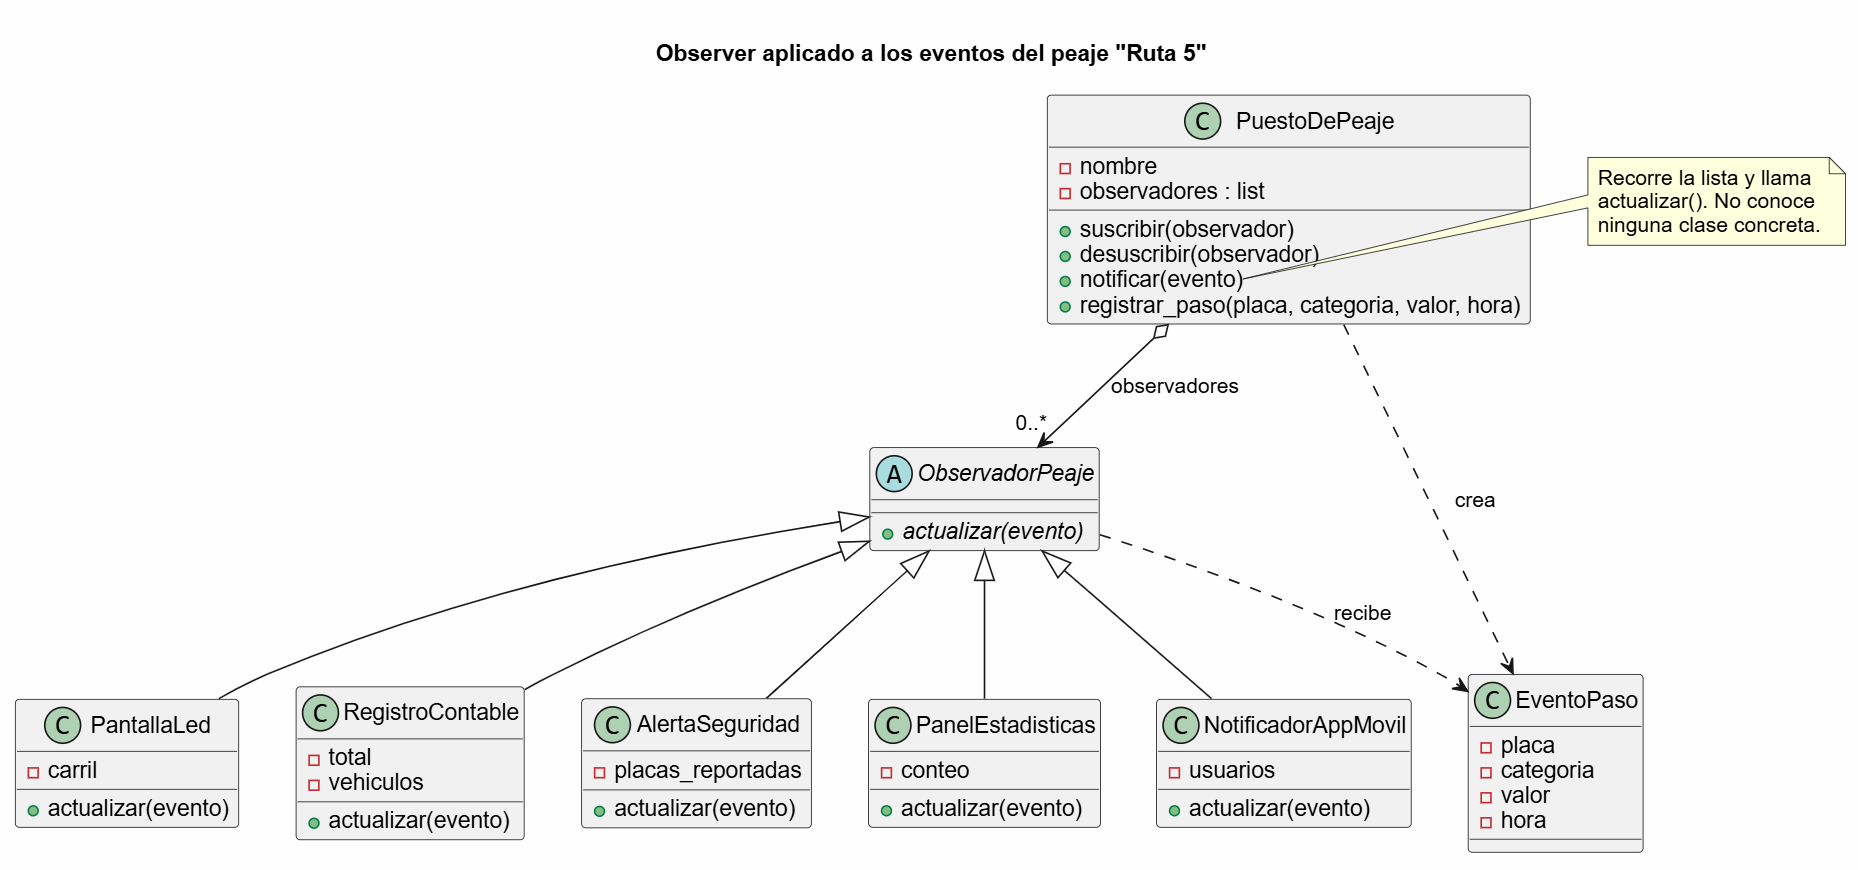


### Código UML

```plantuml
@startuml
title Observer aplicado a los eventos del peaje "Ruta 5"

class PuestoDePeaje {
    - nombre
    - observadores : list
    + suscribir(observador)
    + desuscribir(observador)
    + notificar(evento)
    + registrar_paso(placa, categoria, valor, hora)
}

abstract class ObservadorPeaje {
    + {abstract} actualizar(evento)
}

class PantallaLed {
    - carril
    + actualizar(evento)
}

class RegistroContable {
    - total
    - vehiculos
    + actualizar(evento)
}

class AlertaSeguridad {
    - placas_reportadas
    + actualizar(evento)
}

class PanelEstadisticas {
    - conteo
    + actualizar(evento)
}

class NotificadorAppMovil {
    - usuarios
    + actualizar(evento)
}

class EventoPaso {
    - placa
    - categoria
    - valor
    - hora
}

ObservadorPeaje <|-- PantallaLed
ObservadorPeaje <|-- RegistroContable
ObservadorPeaje <|-- AlertaSeguridad
ObservadorPeaje <|-- PanelEstadisticas
ObservadorPeaje <|-- NotificadorAppMovil

PuestoDePeaje o--> "0..*" ObservadorPeaje : observadores
PuestoDePeaje ..> EventoPaso : crea
ObservadorPeaje ..> EventoPaso : recibe

note right of PuestoDePeaje::notificar
  Recorre la lista y llama
  actualizar(). No conoce
  ninguna clase concreta.
end note
@enduml
```

## ¿Por qué Observer y no otro?

La forma del problema es difusión de uno a muchos, con receptores que no se conocen entre sí y una lista que cambia mientras el sistema está corriendo.

Mediator también desacopla, pero está pensado para comunicación en varias direcciones entre objetos que sí necesitan coordinarse. Acá los subsistemas nunca le responden al peaje ni se hablan entre ellos, así que un mediador sería un intermediario de más.

Chain of Responsibility no encaja por la semántica: en una cadena la petición avanza hasta que alguno la maneja y ahí se detiene. En mi caso todos tienen que recibir el evento siempre, y da igual el orden en que lo reciban.

Command encapsula una petición para poder encolarla o deshacerla, y `EventoPaso` es un dato, no una acción, además nadie va a deshacer el paso de un carro. State tampoco, porque el peaje se comporta igual siempre; lo que cambia es quién está escuchando.

Algo para tener en cuenta: si un observador lanza una excepción se corta la notificación de los que van después en la lista. En algo real cada llamada a `actualizar()` iría dentro de un try/except.